In [1]:
import os
import numpy as np
import pyarrow as pa
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq

from datetime import datetime

%matplotlib widget

import matplotlib.pyplot as plt

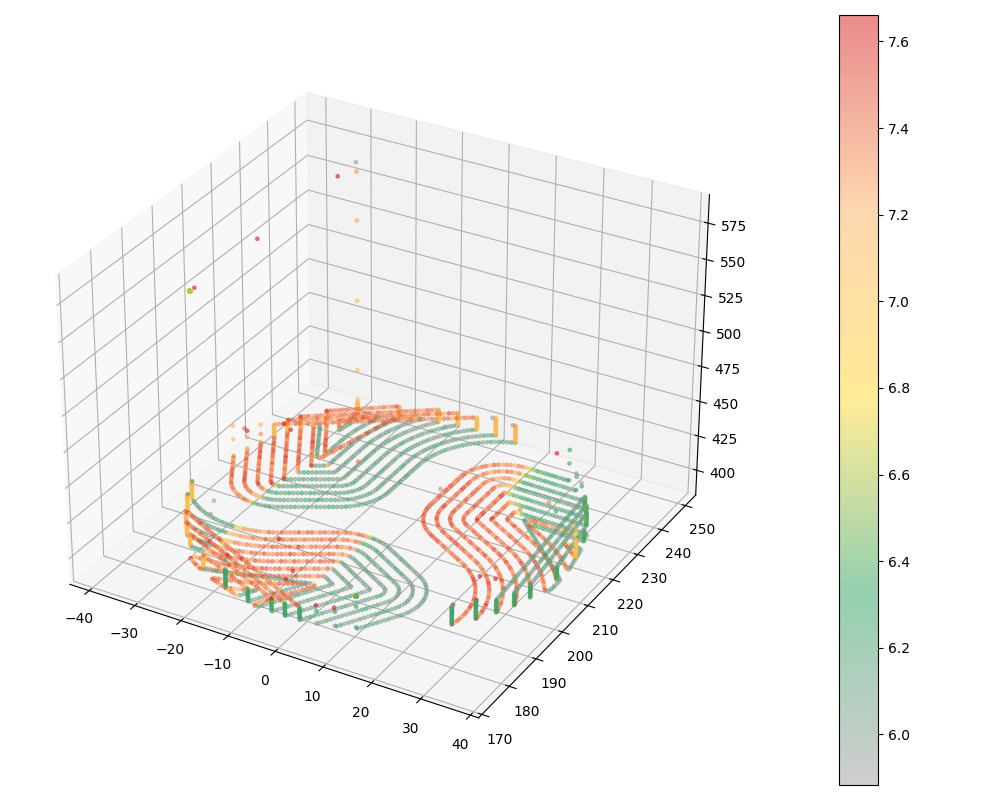

In [26]:
from pathlib import Path

from matplotlib.colors import LinearSegmentedColormap, Normalize

csv_path = Path("../data/milling/IMP-05/processed_data/IMP-05_hfdata.csv")

df = pd.read_csv(csv_path)

# print(df.head())

# n_cols = 10
# fig, ax = plt.subplots(n_cols, 1, figsize=(10, n_cols*2), sharex=True)
# for k in range(n_cols):
#     v = df.iloc[:,k].to_numpy()
#     v_mean = np.mean(v)
#     v_std = np.std(v)
#     ax[k].plot(v)
#     ax[k].set_ylim([v_mean - v_std, v_mean + v_std])
#     ax[k].set_title(f'{k}: {df.columns[k]}')

t = df.iloc[:,0].to_numpy()
t = t - t[0]
x = df.iloc[:,1].to_numpy()
y = df.iloc[:,2].to_numpy()
z = df.iloc[:,3].to_numpy()
f = df.iloc[:,6].to_numpy()
# f = (f - np.mean(f))/(np.std(f)*2)
f_mean = np.mean(f)
f_std = np.std(f)

# fig, ax = plt.subplots()
# ax.set_aspect('equal')
# ax.plot(x, y, '.')

only_nth = 50

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

cmap_force = LinearSegmentedColormap.from_list(
        "gray_green_yellow_orange_red",
        ["#9e9e9e", "#2ca25f", "#ffd92f", "#fdae61", "#d7191c"],
        N=256
    )


norm = Normalize(vmin=f_mean - f_std, vmax=f_mean + f_std)

sc = ax.scatter(
    x[::only_nth],
    y[::only_nth],
    z[::only_nth],          # Höhe
    c=f[::only_nth],        # Farbe nach Kraft
    cmap=cmap_force,
    norm=norm,
    s=6,
    alpha=0.5
)


cbar = fig.colorbar(sc, ax=ax, pad=0.1)

plt.tight_layout()





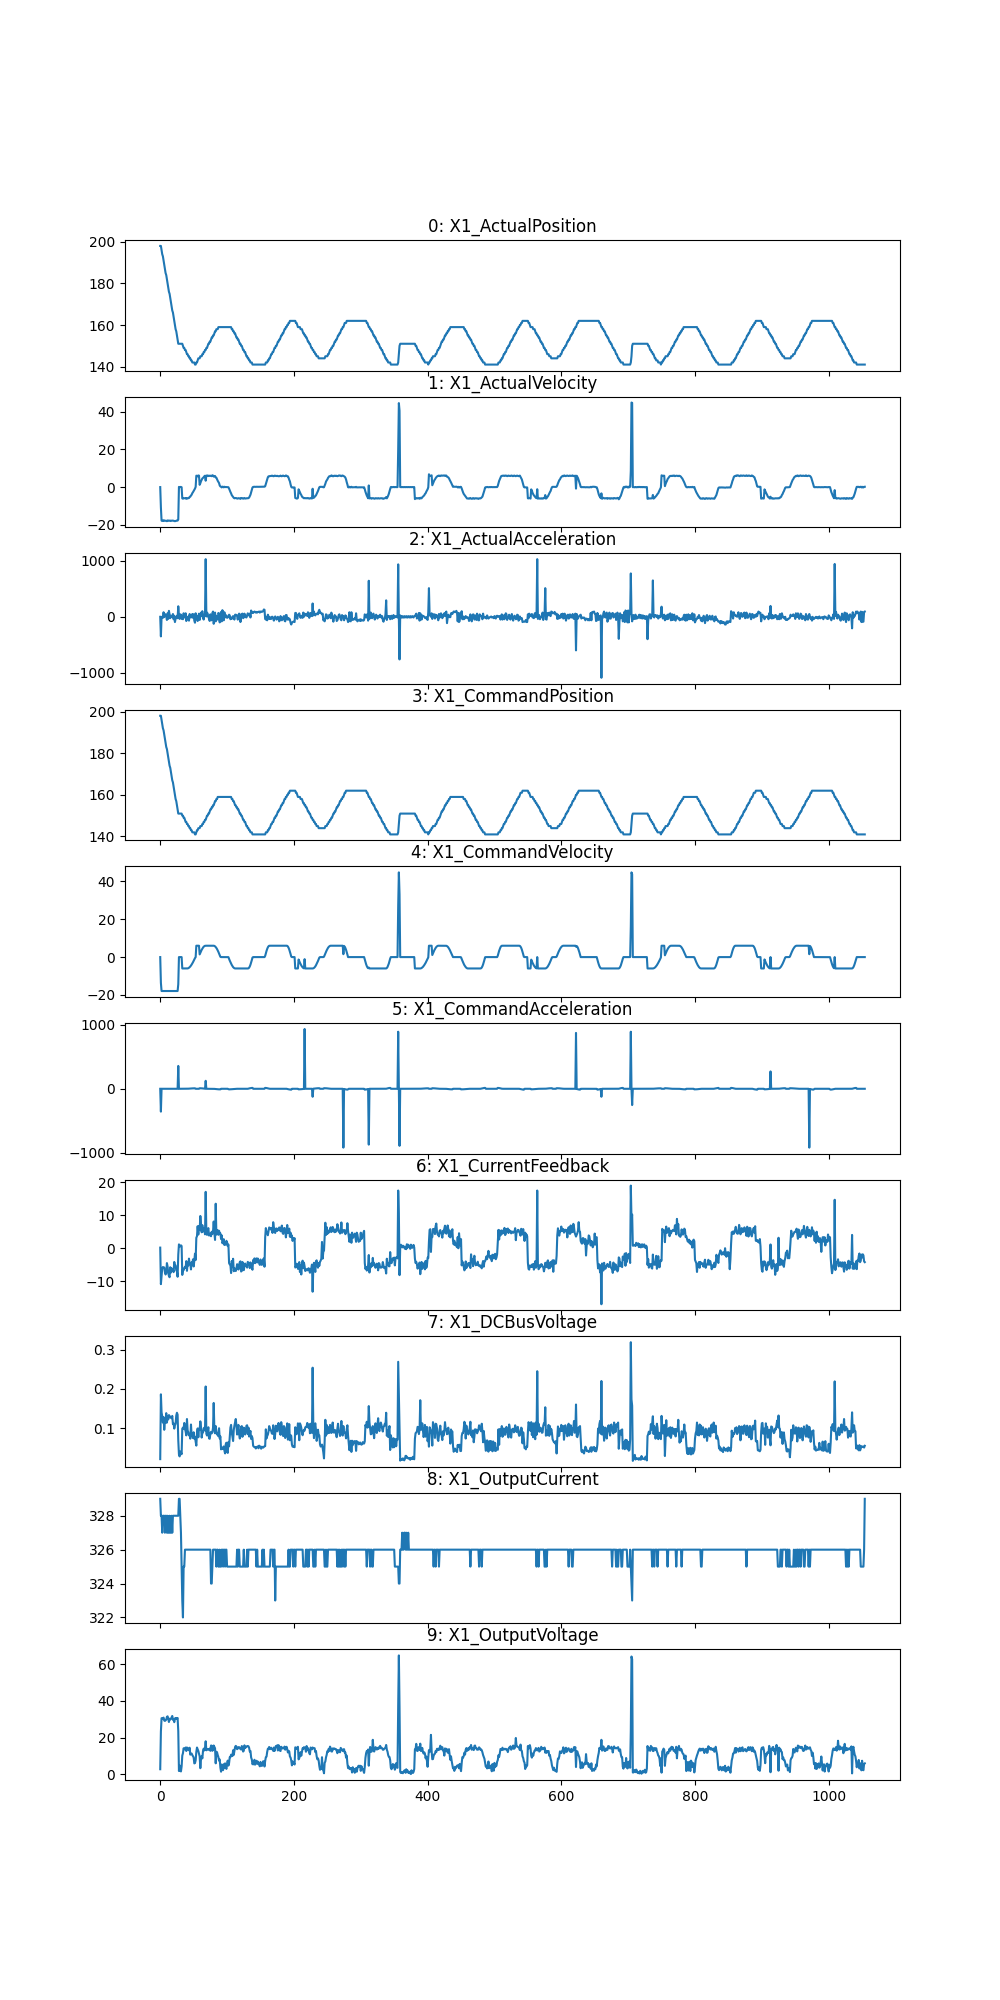

In [32]:
from pathlib import Path

from matplotlib.colors import LinearSegmentedColormap, Normalize

csv_path = Path("../data/cnc_mill_tool_wear/experiment_01.csv")

df = pd.read_csv(csv_path)

# n_cols = len(df.columns)
n_cols = 10
fig, ax = plt.subplots(n_cols, 1, figsize=(10, n_cols*2), sharex=True)
for k in range(n_cols):
    v = df.iloc[:,k].to_numpy()
    # v_mean = np.mean(v)
    # v_std = np.std(v)
    ax[k].plot(v)
    # ax[k].set_ylim([v_mean - v_std, v_mean + v_std])
    ax[k].set_title(f'{k}: {df.columns[k]}')

In [4]:
from pathlib import Path
import numpy as np
import tables

csv_path = Path("../data/milling/M1T1R100C570VB55.h5")

def _read_1d_signal(h5, path):
    arr = h5.get_node(path).read()
    arr = np.asarray(arr)
    # Most signals are stored as shape (1, N); flatten to (N,)
    if arr.ndim == 2 and arr.shape[0] == 1:
        arr = arr[0]
    return arr

with tables.open_file(csv_path, mode="r") as h5:
    # Machine position signals
    tool_position_x = _read_1d_signal(h5, "/signals_machine/tool_position_x")
    tool_position_y = _read_1d_signal(h5, "/signals_machine/tool_position_y")
    tool_position_z = _read_1d_signal(h5, "/signals_machine/tool_position_z")

    # Sensor force signals
    force_sensor_x = _read_1d_signal(h5, "/signals_sensor/force_sensor_x")
    force_sensor_y = _read_1d_signal(h5, "/signals_sensor/force_sensor_y")
    force_sensor_z = _read_1d_signal(h5, "/signals_sensor/force_sensor_z")

    # Time bases (if present)
    time_machine = _read_1d_signal(h5, "/signals_machine/time_machine") if hasattr(h5.root.signals_machine, "time_machine") else None
    time_sensor = _read_1d_signal(h5, "/signals_sensor/time_sensor") if hasattr(h5.root.signals_sensor, "time_sensor") else None

print("tool_position_x:", tool_position_x.shape, tool_position_x.dtype)
print("tool_position_y:", tool_position_y.shape, tool_position_y.dtype)
print("tool_position_z:", tool_position_z.shape, tool_position_z.dtype)
print("force_sensor_x:", force_sensor_x.shape, force_sensor_x.dtype)
print("force_sensor_y:", force_sensor_y.shape, force_sensor_y.dtype)
print("force_sensor_z:", force_sensor_z.shape, force_sensor_z.dtype)

if time_machine is not None:
    print("time_machine:", time_machine.shape, time_machine.dtype, "min/max:", float(np.min(time_machine)), float(np.max(time_machine)))
else:
    print("time_machine: nicht vorhanden")

if time_sensor is not None:
    print("time_sensor:", time_sensor.shape, time_sensor.dtype, "min/max:", float(np.min(time_sensor)), float(np.max(time_sensor)))
else:
    print("time_sensor: nicht vorhanden")

# Optional: combine into stacked arrays
tool_position_xyz = np.column_stack([tool_position_x, tool_position_y, tool_position_z])
force_sensor_xyz = np.column_stack([force_sensor_x, force_sensor_y, force_sensor_z])

print("tool_position_xyz:", tool_position_xyz.shape)
print("force_sensor_xyz:", force_sensor_xyz.shape)

tool_position_x: (2205,) float32
tool_position_y: (2205,) float32
tool_position_z: (2205,) float32
force_sensor_x: (110250,) float32
force_sensor_y: (110250,) float32
force_sensor_z: (110250,) float32
time_machine: (2205,) float32 min/max: 0.0 4.4079999923706055
time_sensor: (110250,) float32 min/max: 0.0 4.40995979309082
tool_position_xyz: (2205, 3)
force_sensor_xyz: (110250, 3)


In [6]:
import os
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq

from datetime import datetime

%matplotlib widget

import matplotlib.pyplot as plt


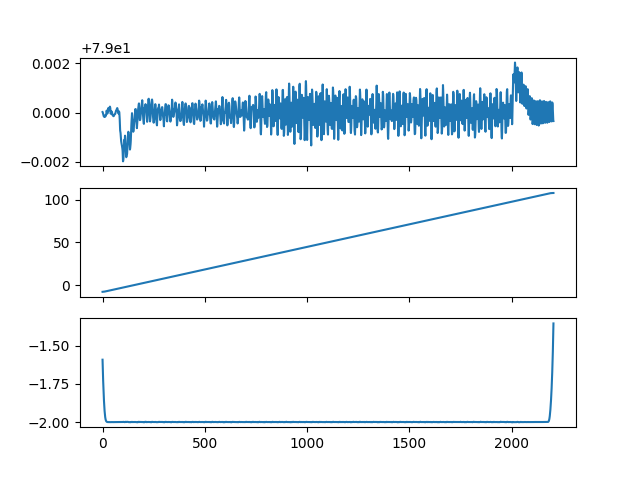

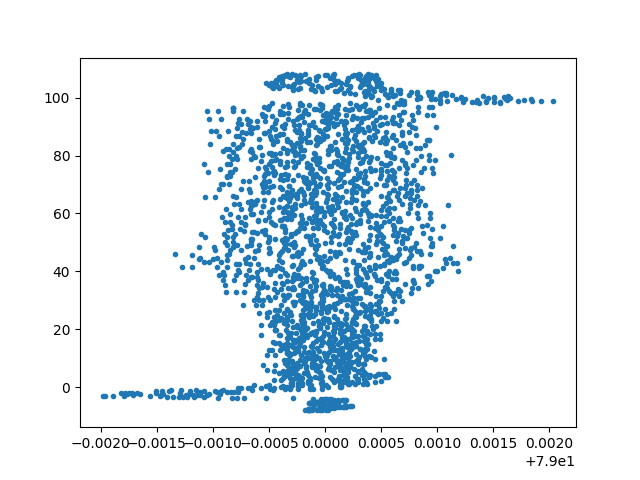

In [13]:
fig, ax = plt.subplots(3, 1, sharex=True)
ax[0].plot(tool_position_x, label="tool_position_x")
ax[1].plot(tool_position_y, label="tool_position_y")
ax[2].plot(tool_position_z, label="tool_position_z")

fig, ax = plt.subplots()
# ax.set_aspect('equal')
ax.plot(tool_position_x, tool_position_y, '.', label="tool_position_xy")

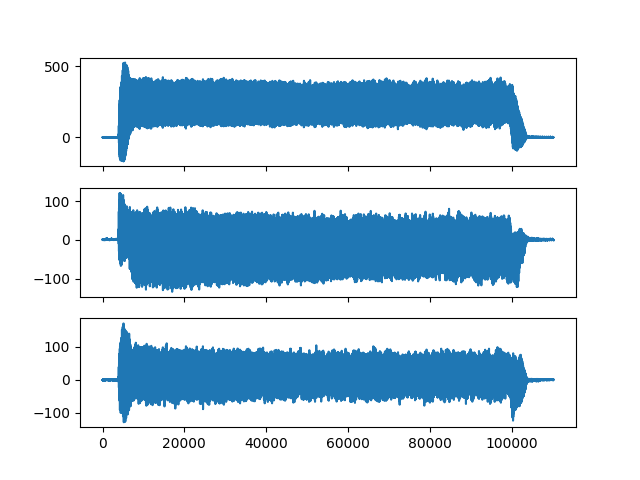

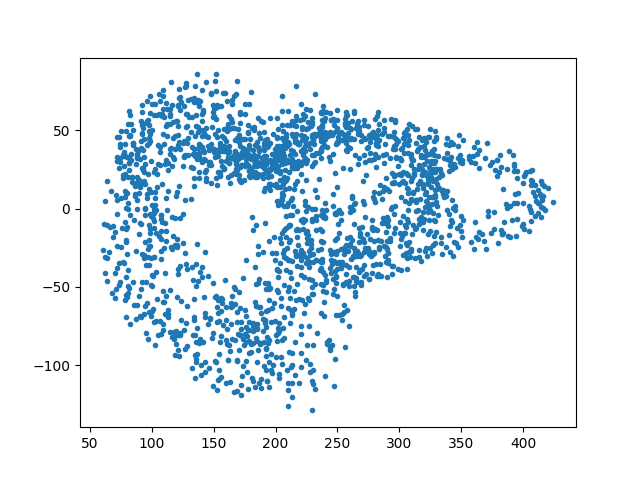

In [ ]:
fig, ax = plt.subplots(3, 1, sharex=True)
ax[0].plot(force_sensor_x, label="force_sensor_x")
ax[1].plot(force_sensor_y, label="force_sensor_y")
ax[2].plot(force_sensor_z, label="force_sensor_z")

fig, ax = plt.subplots()
# ax.set_aspect('equal')
ax.plot(force_sensor_x[10000:12000], force_sensor_y[10000:12000], '.', label="force_sensor_xy")

x_ = force_sensor_x[10000:12000]
y_ = force_sensor_y[10000:12000]

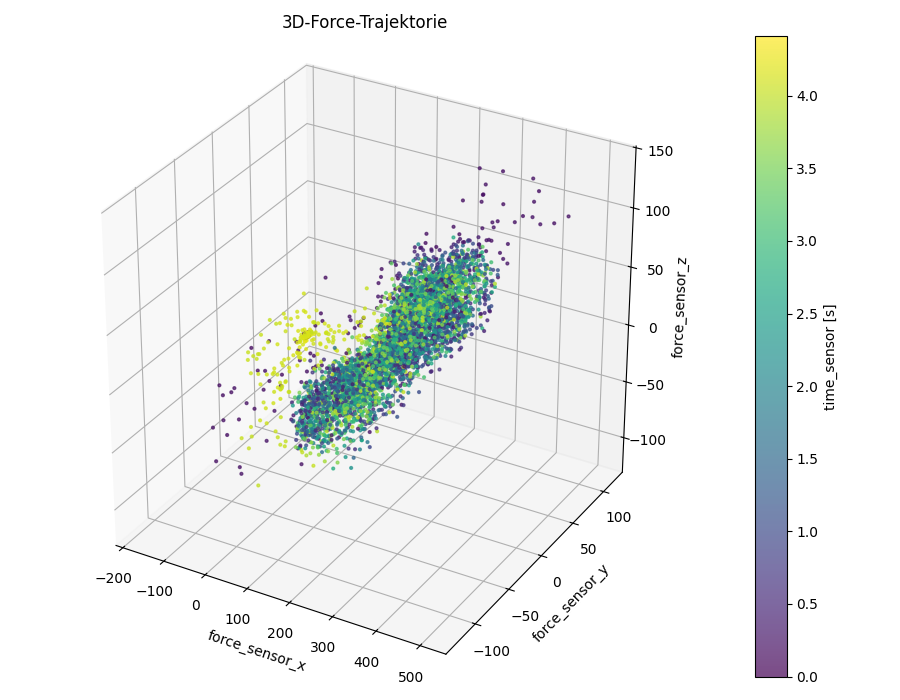

In [19]:
# 3D-Plot der drei Force-Signale
step = 20  # Ausdünnung für flüssige Darstellung
fx = force_sensor_x[::step]
fy = force_sensor_y[::step]
fz = force_sensor_z[::step]

if time_sensor is not None:
    c = time_sensor[::step]
    c_label = "time_sensor [s]"
else:
    c = np.arange(len(fx))
    c_label = "Sample Index"

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(fx, fy, fz, c=c, s=4, alpha=0.7, cmap="viridis")

ax.set_xlabel("force_sensor_x")
ax.set_ylabel("force_sensor_y")
ax.set_zlabel("force_sensor_z")
ax.set_title("3D-Force-Trajektorie")

cbar = fig.colorbar(sc, ax=ax, pad=0.08)
cbar.set_label(c_label)

# Optional: gleiche visuelle Achsenskalierung
ax.set_box_aspect((1, 1, 1))
plt.tight_layout()